In [41]:
from pathlib import Path
from urllib.request import urlretrieve

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"

Path("data").mkdir(parents=True, exist_ok=True)
urlretrieve(url, "data/tinyshakespeare.txt")

print("Downloaded to data/tinyshakespeare.txt")

Downloaded to data/tinyshakespeare.txt


In [42]:
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers import Tokenizer

tokenizer = Tokenizer(BPE(unk_token="[UNK]"))

trainer = BpeTrainer(vocab_size=500, min_frequency=2, special_tokens=["[PAD]","[UNK]", "[BOS]", "[EOS]"])

tokenizer.train(["data/tinyshakespeare.txt"], trainer)

encoded = tokenizer.encode("To be, or not to be")
print(encoded.tokens)
print(encoded.ids)




['To ', 'b', 'e, ', 'or ', 'not ', 'to ', 'be']
[231, 44, 114, 406, 140, 95, 181]


In [43]:
seq_length = 50
text = open("data/tinyshakespeare.txt", "r", encoding="utf-8").read()
token_ids = tokenizer.encode(text).ids
split_idx = int(0.8 * len(token_ids))
train_ids = token_ids[:split_idx]
val_ids = token_ids[split_idx:]

train_input_ids = []
train_target_ids = []

val_input_ids = []
val_target_ids = []

for i in range(0, len(train_ids) - seq_length):
   train_input_ids.append(train_ids[i : i + seq_length])
   train_target_ids.append(train_ids[i + 1 : i + 1 + seq_length])

for i in range(0, len(val_ids) - seq_length):
   val_input_ids.append(val_ids[i : i + seq_length])
   val_target_ids.append(val_ids[i + 1 : i + 1 + seq_length])

print(train_input_ids[0])
print(train_target_ids[0])
print(val_input_ids[0])
print(val_target_ids[0])


[22, 434, 19, 128, 51, 68, 83, 80, 18, 47, 462, 347, 411, 45, 139, 73, 79, 78, 48, 145, 180, 74, 334, 498, 284, 381, 85, 4, 17, 88, 80, 35, 58, 381, 74, 284, 381, 85, 4, 22, 434, 19, 128, 51, 68, 83, 80, 389, 5, 233]
[434, 19, 128, 51, 68, 83, 80, 18, 47, 462, 347, 411, 45, 139, 73, 79, 78, 48, 145, 180, 74, 334, 498, 284, 381, 85, 4, 17, 88, 80, 35, 58, 381, 74, 284, 381, 85, 4, 22, 434, 19, 128, 51, 68, 83, 80, 389, 5, 233, 43]
[482, 220, 56, 186, 100, 84, 359, 62, 189, 177, 493, 154, 198, 90, 18, 78, 58, 299, 62, 185, 87, 116, 46, 337, 77, 152, 118, 208, 384, 4, 25, 35, 17, 18, 317, 28, 279, 421, 275, 62, 291, 63, 69, 295, 87, 47, 14, 218, 174, 224]
[220, 56, 186, 100, 84, 359, 62, 189, 177, 493, 154, 198, 90, 18, 78, 58, 299, 62, 185, 87, 116, 46, 337, 77, 152, 118, 208, 384, 4, 25, 35, 17, 18, 317, 28, 279, 421, 275, 62, 291, 63, 69, 295, 87, 47, 14, 218, 174, 224, 141]


In [44]:
import torch
import torch.nn as nn

train_input_ids = torch.tensor(train_input_ids, dtype=torch.long)
train_target_ids = torch.tensor(train_target_ids, dtype=torch.long)
val_input_ids = torch.tensor(val_input_ids, dtype=torch.long)
val_target_ids = torch.tensor(val_target_ids, dtype=torch.long)

vocab_size = tokenizer.get_vocab_size()

d_model = 128
seq_length = 50

print(train_input_ids.shape)
print(train_target_ids.shape)
print(val_input_ids.shape)
print(val_target_ids.shape)
print(vocab_size)


torch.Size([410794, 50])
torch.Size([410794, 50])
torch.Size([102662, 50])
torch.Size([102662, 50])
500


In [45]:
import random
import numpy as np

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [46]:
import math

class PositionalEncoding(torch.nn.Module):
    def __init__(self, d_model, seq_length):
        super().__init__()
        
        pe = torch.zeros(seq_length,d_model)
        position = torch.arange(0,seq_length,dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0,d_model,2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer("pe", pe.unsqueeze(0))
        
    def forward(self,x):
        return x + self.pe[:, :x.size(1)]
        

In [47]:
import torch.nn.functional as F
class RMSNorm(nn.Module):
    def __init__(self, d_model, eps=1e-8):
        super().__init__()
        self.eps = eps
        self.scale = nn.Parameter(torch.ones(d_model))
    
    def forward(self, x):
        rms = torch.sqrt(torch.mean(x ** 2, dim=-1, keepdim=True) + self.eps)
        return self.scale * (x / rms)



In [48]:
class SelfAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        #Will split the heads in the forward pass
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        
        self.out_proj = nn.Linear(d_model, d_model)
        
    def forward(self, x):
        B, S, C = x.shape
        
        Q = self.q_proj(x)
        K = self.k_proj(x)
        V = self.v_proj(x)
        
        Q = Q.view(B, S, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(B, S, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(B, S, self.num_heads, self.head_dim).transpose(1, 2)

        scores = Q @ K.transpose(-2, -1)/math.sqrt(self.head_dim)
        
        causal_mask = torch.triu(
            torch.ones(S, S, device=x.device), diagonal=1
        ).bool()
        
        scores = scores.masked_fill(causal_mask, float("-inf"))
        
        attn_weights = torch.softmax(scores, dim=-1)
        attn_output = attn_weights @ V
        
        attn_output = attn_output.transpose(1, 2).contiguous().view(B, S, C)
        
        return self.out_proj(attn_output), attn_weights
        
        

In [49]:
class FeedForward(nn.Module):
    def __init__(self,d_model):
        super().__init__()
        self.linear1 = nn.Linear(d_model,4*d_model)
        self.activation = nn.GELU()
        self.linear2 = nn.Linear(4*d_model,d_model)
        
    def forward(self,x):
        return self.linear2(self.activation(self.linear1(x)))
   

In [50]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.attn = SelfAttention(d_model, num_heads)
        self.norm1 = RMSNorm(d_model)
        self.ffn = FeedForward(d_model)
        self.norm2 = RMSNorm(d_model)
        
    def forward(self, x):
        attn_output, attn_weights = self.attn(self.norm1(x))
        x = x+attn_output
        ffn_output = self.ffn(self.norm2(x))
        x = x+ffn_output
        
        return x,attn_weights

In [51]:
class TinyTransformerLM(nn.Module):
    def __init__(self, vocab_size, d_model, seq_length, num_heads, num_layers):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, seq_length)
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads) for _ in range(num_layers)
        ])
        self.final_norm = RMSNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, input_ids):
        x = self.token_embedding(input_ids)
        x = self.pos_encoding(x)

        attention_maps = []
        for block in self.blocks:
            x, attn_weights = block(x)
            attention_maps.append(attn_weights)

        x = self.final_norm(x)
        logits = self.lm_head(x)

        return logits, attention_maps


In [52]:
def train(model, optimizer, criterion, train_loader, device):
    model.train()
    total_loss = 0
    
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits, _ = model(x_batch)
        loss = criterion(logits.view(-1, logits.shape[-1]), y_batch.view(-1))
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

In [53]:
def evaluate(model, criterion, val_loader, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            logits, _ = model(x_batch)
            loss = criterion(
                logits.reshape(-1,vocab_size),
                y_batch.reshape(-1)
            )
            total_loss += loss.item()

    return total_loss / len(val_loader)

In [54]:
from torch.utils.data import TensorDataset, DataLoader
epochs = 5
num_heads = 4
num_layers = 2
learning_rate = 1e-4
batch_size = 64
train_dataset = TensorDataset(train_input_ids, train_target_ids)
val_dataset = TensorDataset(val_input_ids, val_target_ids)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_losses = []
val_losses = []

generator = torch.Generator()
generator.manual_seed(seed)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=generator)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

model = TinyTransformerLM(vocab_size, d_model, seq_length, num_heads, num_layers).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

for epoch in range(epochs):
    train_loss = train(model, optimizer, criterion, train_loader, device)
    val_loss = evaluate(model, criterion, val_loader, device)
    val_perplexity = math.exp(val_loss)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    print(
        f"Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Perplexity: {val_perplexity:.4f}"
    )
    

Epoch [1/5], Train Loss: 5.3166, Val Loss: 5.3602, Val Perplexity: 212.7666
Epoch [2/5], Train Loss: 5.2724, Val Loss: 5.2418, Val Perplexity: 189.0031
Epoch [3/5], Train Loss: 5.0344, Val Loss: 4.9952, Val Perplexity: 147.7036
Epoch [4/5], Train Loss: 4.8937, Val Loss: 4.9096, Val Perplexity: 135.5799
Epoch [5/5], Train Loss: 4.8147, Val Loss: 4.8309, Val Perplexity: 125.3186


In [55]:
model.eval()
with torch.no_grad():
    sample_input = train_input_ids[:2].to(device)
    
    x = model.token_embedding(sample_input)
    x = model.pos_encoding(x)
    
    custom_attn = model.blocks[0].attn
    custom_output , custom_weights = custom_attn(x)
    
    reference_attn = nn.MultiheadAttention(
        embed_dim=d_model, 
        num_heads=num_heads, 
        dropout=0.0, 
        batch_first=True
        ).to(device)
    
    reference_attn.in_proj_weight.copy_(
        torch.cat(
            [
                custom_attn.q_proj.weight,
                custom_attn.k_proj.weight,
                custom_attn.v_proj.weight,
            ],
            dim=0,
        )
    )

    reference_attn.in_proj_bias.copy_(
        torch.cat(
            [
                custom_attn.q_proj.bias,
                custom_attn.k_proj.bias,
                custom_attn.v_proj.bias,
            ],
            dim=0,
        )
    )

    reference_attn.out_proj.weight.copy_(custom_attn.out_proj.weight)
    reference_attn.out_proj.bias.copy_(custom_attn.out_proj.bias)
    
    causal_mask = torch.triu(
        torch.ones(seq_length, seq_length, device=device),
        diagonal=1
    ).bool()

    reference_output, reference_weights = reference_attn(
        x,
        x,
        x,
        attn_mask=causal_mask,
        need_weights=True,
        average_attn_weights=False
    )

    output_diff = (custom_output - reference_output).abs().max().item()
    weights_diff = (custom_weights - reference_weights).abs().max().item()

print(f"Max output difference: {output_diff:.8f}")
print(f"Max attention weight difference: {weights_diff:.8f}")
    
    

Max output difference: 0.00000001
Max attention weight difference: 0.00000000


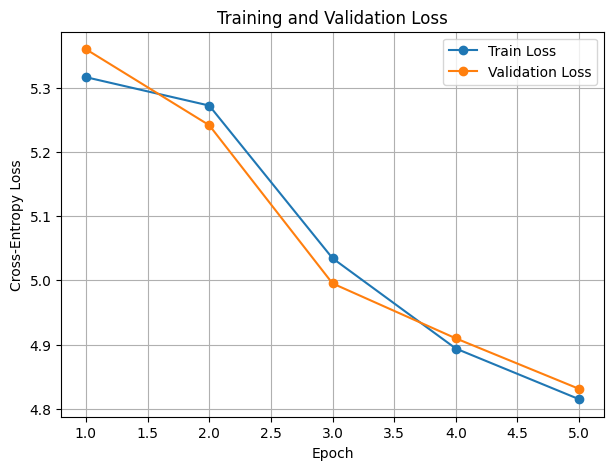

In [56]:
import matplotlib.pyplot as plt
import math

epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(7, 5))
plt.plot(epochs_range, train_losses, marker="o", label="Train Loss")
plt.plot(epochs_range, val_losses, marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


In [57]:
best_val_loss = min(val_losses)
best_val_ppl = math.exp(best_val_loss)

print(f"Best Val Loss: {best_val_loss:.4f}")
print(f"Best Val PPL: {best_val_ppl:.4f}")

Best Val Loss: 4.8309
Best Val PPL: 125.3186


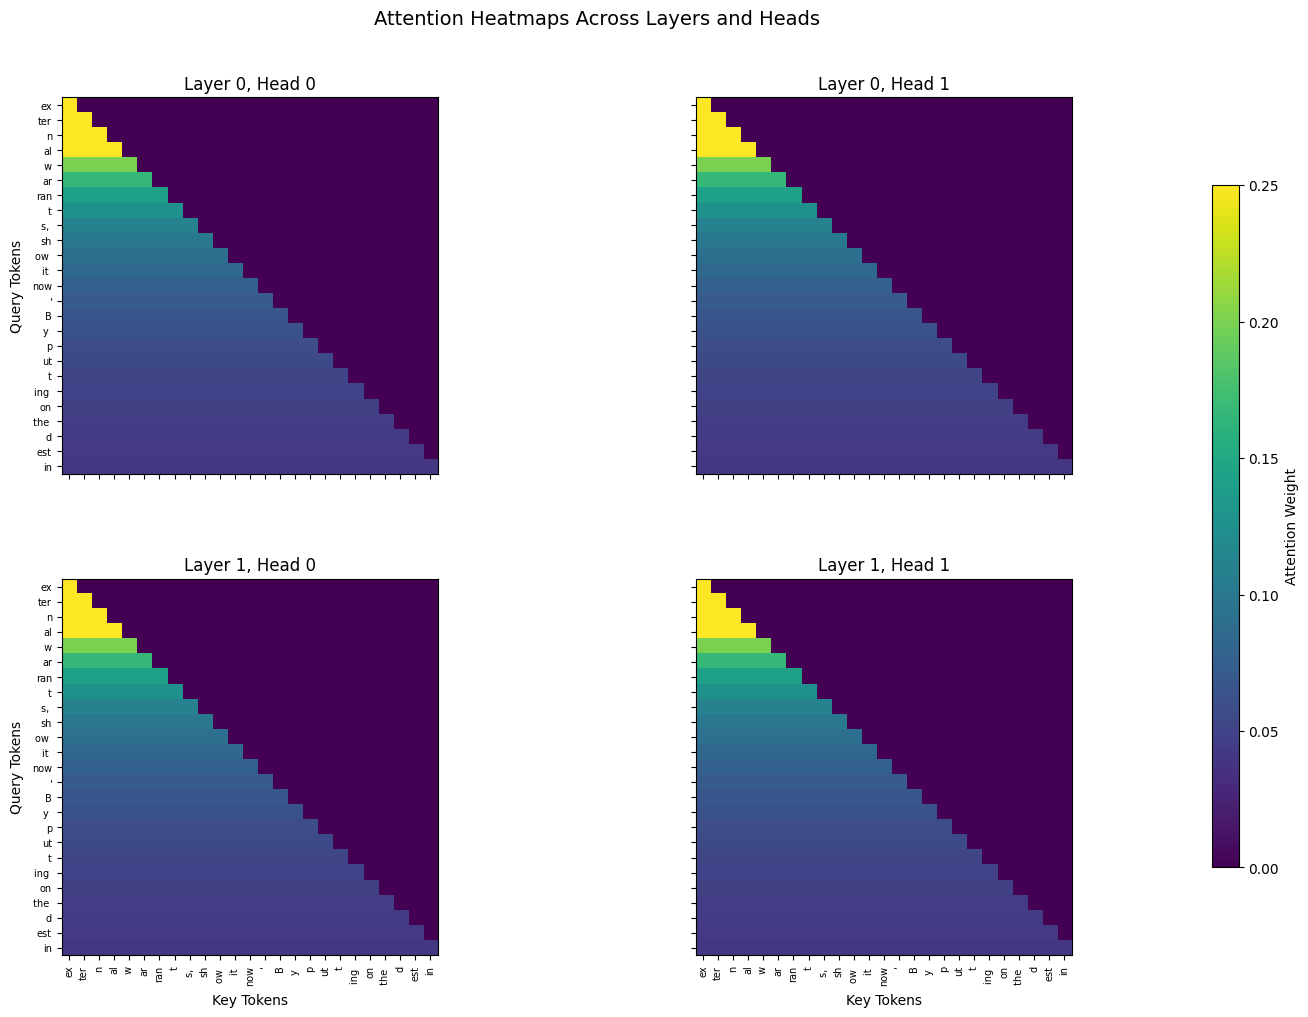

In [58]:
plot_len = 25
sample_idx = 0
layers_to_plot = [0, 1]
heads_to_plot = [0, 1]

model.eval()
with torch.no_grad():
    _, attention_maps = model(val_input_ids[sample_idx:sample_idx+1].to(device))

sample_token_ids = val_input_ids[sample_idx][:plot_len].tolist()
token_labels = [tokenizer.id_to_token(token_id) for token_id in sample_token_ids]

fig, axes = plt.subplots(len(layers_to_plot), len(heads_to_plot), figsize=(15, 11), sharex=True, sharey=True)

for row, layer_idx in enumerate(layers_to_plot):
    for col, head_idx in enumerate(heads_to_plot):
        ax = axes[row, col]
        attn = attention_maps[layer_idx][0, head_idx].cpu()
        im = ax.imshow(attn[:plot_len, :plot_len], cmap="viridis", vmin=0, vmax=0.25)
        ax.set_title(f"Layer {layer_idx}, Head {head_idx}")
        ax.set_xticks(range(plot_len))
        ax.set_yticks(range(plot_len))
        ax.set_xticklabels(token_labels, rotation=90, fontsize=7)
        ax.set_yticklabels(token_labels, fontsize=7)
        if row == len(layers_to_plot) - 1:
            ax.set_xlabel("Key Tokens")
        if col == 0:
            ax.set_ylabel("Query Tokens")

fig.suptitle("Attention Heatmaps Across Layers and Heads", fontsize=14)
fig.subplots_adjust(left=0.08, right=0.88, bottom=0.12, top=0.90, wspace=0.12, hspace=0.28)
cbar_ax = fig.add_axes([0.91, 0.20, 0.018, 0.62])
fig.colorbar(im, cax=cbar_ax, label="Attention Weight")
plt.show()


The attention heatmap shows the expected causal structure: tokens attend only to themselves and earlier tokens, not future tokens. The strongest weights often appear near the diagonal, meaning the model frequently relies on recent context when predicting the next token. This makes sense for language modeling on short Shakespeare sequences, where nearby words and subword pieces are usually most informative. The heatmap also confirms that the causal mask is working correctly.